# **CMPE454 Applied LLMs - Assignment (Medical Domain)**



## Student Information
**Name:** Mohamed Anies Awad Satti

**Student ID:** 22243510145





---
## AI Usage Disclosure
Parts of the code in this notebook (specifically the data generation script, perplexity calculation, and plotting logic) were directly generated with the assistance of Generative AI tools (Gemini 3 / ChatGPT 5.2). Other parts were generated by me utilizing hugging face documentations, but debugged by AI to ensure PyTorch best practices, like training arguments and model heads. I have reviewed, verified, and modified all code to ensure it meets the assignment constraints (124M model, fp16=True, batch size limits). The interpretation of results in the report is entirely my own work.

---



## Phase 0: Setting-up files

In this phase I set-up the files which I need for this assignment: 'pretrain.txt', 'classification.csv', 'instruct.json', and to keep my code clean I also read from the file 'general_sentences.txt' (was created separatly) which includes 250 lines of general (chit-chat) data for 'classification.csv' file.

I import 5 libraries:
1. **json**: to handle JSON formatted Q&A pairs
2. **csv**: to create 'classification.csv' file
3. **random**: to shuffle rows order randomly to avoid ordering bias
4. **os**: to calculate 'pretrain.txt' file size and ensure it's within the range 5-10 MB
5. **load_dataset**: a hugging face library to download the 'pubmed-abstract' dataset

In [ ]:
import json
import csv
import random
import os
from datasets import load_dataset

In [ ]:
#=== 1. DOWNLOAD MEDICAL DATA ===#
print("Downloading data from 'uiyunkim-hub/pubmed-abstract' dataset...")

# I use "streaming=True" to avoid downloading the whole 27GB
medical_dataset = load_dataset("uiyunkim-hub/pubmed-abstract", split="train", streaming=True)

# Extract first 6000 clean abstracts for our Domain Data
medical_text_samples = []
print("Processing abstracts...")

for sample in medical_dataset:
    text = sample.get("abstract")

    # Remove newlines inside the text to keep it one-line per sample
    clean_text = text.replace("\n", " ").strip()

    # Ignore empty or short rows
    if len(clean_text) > 100:
        medical_text_samples.append(clean_text)

    if len(medical_text_samples) >= 6000: # Stop when we reach target data
        break

print(f"Loaded {len(medical_text_samples)} medical abstracts.\n")


#=== 2. GENERATE FILE 1: pretrain.txt ===#
print("\nCreating pretrain.txt...")
with open("pretrain.txt", "w", encoding="utf-8") as f:
    for sentence in medical_text_samples:
        f.write(sentence + "\n")

# Check size to ensure it meets the 5-10MB requirement
size_mb = os.path.getsize('pretrain.txt') / (1024 * 1024)
if(size_mb >= 5.0 and size_mb <= 10.0):
  print(f"-> Success! 'pretrain.txt' created. Size: {size_mb:.2f} MB")
else:
  print(f"File size is not within the range 5-10MB - Size: {size_mb:.2f} MB")


#=== 3. GENERATE FILE 2: classification.csv ===#
# A. Get general data from a file (250 row)
print("Reading 'general_sentences.txt'...")

general_text_samples = []
try:
    with open("/content/general_sentences.txt", "r", encoding="utf-8") as f:
        # Read lines and remove whitespace/newlines
        general_text_samples = [line.strip() for line in f if line.strip()]

    print(f"Loaded {len(general_text_samples)} general (chit-chat) sentences.")

    # Safety Check: If you have fewer than 250 lines, we loop them to prevent crashing
    if len(general_text_samples) < 250:
        print(f"Warning: File only has {len(general_text_samples)} lines. Repeating content to reach 250.")
        general_text_samples = general_text_samples * (250 // len(general_text_samples) + 1)

except FileNotFoundError:
    print("ERROR: Could not find 'general_sentences.txt'. Please upload it to Colab files!")
    # Stop execution if file is missing
    raise

# B. Get medical data (250 row)
print("\nCreating classification.csv...")

data_rows = []
# 250 Medical Sentences (Label 1)
for i in range(250):
    data_rows.append([medical_text_samples[i], 1])

# C. Combine both medical and general data
# 250 General Sentences (Label 0)
for i in range(250):
    text = general_text_samples[i] # Reading from your loaded list
    data_rows.append([text, 0])

# Shuffle to mix them up to reduce bias due to ordering
random.shuffle(data_rows)

with open("classification.csv", "w", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)
    writer.writerow(["text", "label"]) # File Headers
    writer.writerows(data_rows)
print(f"-> Success! 'classification.csv' created with {len(data_rows)} rows.")


#=== 4. GENERATE FILE 3: instruct.json ===#
# 50 Medical Q&A pairs
print("\nCreating instruct.json...")

medical_qa_pairs = [
  {"instruction": "What is the primary symptom of hypertension?", "response": "Hypertension is often asymptomatic, but severe cases may present with headaches, shortness of breath, or nosebleeds."},
  {"instruction": "Explain the function of insulin.", "response": "Insulin is a hormone produced by the pancreas that regulates blood glucose levels by facilitating cellular glucose uptake."},
  {"instruction": "What are the common risks of general anesthesia?", "response": "Risks include nausea, vomiting, sore throat, confusion, and rarely, malignant hyperthermia or cardiac complications."},
  {"instruction": "Define myocardial infarction.", "response": "Myocardial infarction, commonly known as a heart attack, occurs when blood flow is blocked to part of the heart muscle."},
  {"instruction": "What is the purpose of a biopsy?", "response": "A biopsy is performed to remove tissue or cells for laboratory analysis to help diagnose disease, especially cancer."},
  {"instruction": "What is type 2 diabetes?", "response": "Type 2 diabetes is a chronic condition characterized by insulin resistance and impaired blood glucose regulation."},
  {"instruction": "What is the difference between a virus and bacteria?", "response": "Bacteria are living organisms that can reproduce independently, while viruses require a host cell to replicate."},
  {"instruction": "What are antibiotics used for?", "response": "Antibiotics are used to treat bacterial infections by killing bacteria or preventing their growth."},
  {"instruction": "Describe the symptoms of asthma.", "response": "Asthma symptoms include wheezing, shortness of breath, chest tightness, and coughing."},
  {"instruction": "What is a placebo?", "response": "A placebo is an inactive substance or treatment used as a control in clinical research studies."},

   {"instruction": "What is the role of white blood cells?", "response": "White blood cells help protect the body by fighting infections and foreign invaders."},
  {"instruction": "What causes anemia?", "response": "Anemia is caused by a deficiency in red blood cells or hemoglobin, often due to iron deficiency or blood loss."},
  {"instruction": "What is an MRI scan?", "response": "An MRI scan is a medical imaging technique that uses magnetic fields and radio waves to create detailed images of the body."},
  {"instruction": "What are the symptoms of a stroke?", "response": "Stroke symptoms include sudden weakness, facial drooping, speech difficulty, and loss of coordination."},
  {"instruction": "Define metastasis.", "response": "Metastasis is the spread of cancer cells from the original site to other parts of the body."},
  {"instruction": "What is the purpose of a clinical trial?", "response": "Clinical trials evaluate the safety and effectiveness of medical treatments in human participants."},
  {"instruction": "What is sepsis?", "response": "Sepsis is a life-threatening condition caused by an extreme immune response to infection."},
  {"instruction": "How do vaccines work?", "response": "Vaccines stimulate the immune system to recognize and fight specific pathogens without causing disease."},
  {"instruction": "What is chronic obstructive pulmonary disease (COPD)?", "response": "COPD is a progressive lung disease characterized by airflow limitation and breathing difficulty."},
  {"instruction": "What is the function of the kidneys?", "response": "The kidneys filter waste products from the blood and regulate fluid and electrolyte balance."},

  {"instruction": "What is osteoporosis?", "response": "Osteoporosis is a condition characterized by weakened bones and an increased risk of fractures."},
  {"instruction": "What does BMI stand for?", "response": "BMI stands for Body Mass Index, a measure used to assess body weight relative to height."},
  {"instruction": "What are common symptoms of depression?", "response": "Symptoms include persistent sadness, loss of interest, fatigue, and difficulty concentrating."},
  {"instruction": "What is an ECG used for?", "response": "An ECG records the electrical activity of the heart to detect rhythm and conduction abnormalities."},
  {"instruction": "What is an autoimmune disease?", "response": "An autoimmune disease occurs when the immune system attacks the body’s own healthy tissues."},
  {"instruction": "What is hypoglycemia?", "response": "Hypoglycemia is a condition in which blood glucose levels are abnormally low."},
  {"instruction": "What is insomnia?", "response": "Insomnia is a sleep disorder involving difficulty falling asleep, staying asleep, or waking too early."},
  {"instruction": "What is the function of the liver?", "response": "The liver detoxifies harmful substances, metabolizes nutrients, produces bile, and supports digestion."},
  {"instruction": "What is an allergic reaction?", "response": "An allergic reaction is an immune response to a harmless substance that causes symptoms such as itching or swelling."},
  {"instruction": "What causes food poisoning?", "response": "Food poisoning is caused by consuming contaminated food or beverages containing harmful bacteria, viruses, or toxins."},

  {"instruction": "What is a CT scan?", "response": "A CT scan uses X-rays and computer processing to create detailed cross-sectional images of the body."},
  {"instruction": "What is heart failure?", "response": "Heart failure occurs when the heart cannot pump blood effectively to meet the body's needs."},
  {"instruction": "What are probiotics?", "response": "Probiotics are beneficial microorganisms that help maintain a healthy gut microbiome."},
  {"instruction": "What is rheumatoid arthritis?", "response": "Rheumatoid arthritis is an autoimmune disease that causes chronic inflammation of the joints."},
  {"instruction": "What is dehydration?", "response": "Dehydration occurs when the body loses more fluids than it takes in, leading to impaired function."},
  {"instruction": "What is hepatitis?", "response": "Hepatitis is inflammation of the liver, often caused by viral infections or toxins."},
  {"instruction": "What is chemotherapy?", "response": "Chemotherapy is a treatment that uses drugs to kill or slow the growth of cancer cells."},
  {"instruction": "What is a blood transfusion?", "response": "A blood transfusion is a medical procedure in which blood or blood components are given to a patient."},
  {"instruction": "What is physical therapy?", "response": "Physical therapy helps improve movement, strength, and function through targeted exercises and techniques."},
  {"instruction": "What is an ulcer?", "response": "An ulcer is an open sore that develops on the lining of the stomach, intestines, or skin."},

  {"instruction": "What is Parkinson’s disease?", "response": "Parkinson’s disease is a progressive neurological disorder that affects movement, causing tremors, stiffness, and slowed motion."},
  {"instruction": "What is the role of platelets?", "response": "Platelets help with blood clotting by forming plugs at sites of blood vessel injury to prevent excessive bleeding."},
  {"instruction": "What is pneumonia?", "response": "Pneumonia is an infection of the lungs that causes inflammation of the air sacs, which may fill with fluid or pus."},
  {"instruction": "What is the purpose of dialysis?", "response": "Dialysis is a medical procedure that removes waste products and excess fluid from the blood when the kidneys cannot function properly."},
  {"instruction": "What is epilepsy?", "response": "Epilepsy is a neurological disorder characterized by recurrent, unprovoked seizures due to abnormal brain activity."},
  {"instruction": "What is the difference between acute and chronic diseases?", "response": "Acute diseases develop suddenly and last a short time, while chronic diseases are long-lasting and often require ongoing management."},
  {"instruction": "What is hyperthyroidism?", "response": "Hyperthyroidism is a condition in which the thyroid gland produces excessive amounts of thyroid hormones."},
  {"instruction": "What is the purpose of screening tests?", "response": "Screening tests are used to detect diseases early in people who do not yet show symptoms."},
  {"instruction": "What is shock in medical terms?", "response": "Shock is a life-threatening condition in which blood flow to organs is insufficient, leading to tissue damage."},
  {"instruction": "What is the function of the pancreas?", "response": "The pancreas produces digestive enzymes and hormones such as insulin that regulate blood sugar levels."}
]

final_json_data = medical_qa_pairs[:50] # Take only 50 pairs for checking

with open("instruct.json", "w", encoding="utf-8") as f:
    json.dump(final_json_data, f, indent=4) # JSON pretty-format
print(f"-> Success! 'instruct.json' created with {len(final_json_data)} pairs.")

Resolving data files:   0%|          | 0/52 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/52 [00:00<?, ?it/s]

Processing abstracts...
Loaded 6000 medical abstracts.


Creating pretrain.txt...
-> Success! 'pretrain.txt' created. Size: 5.83 MB
Reading 'general_sentences.txt'...
Loaded 250 general (chit-chat) sentences.

Creating classification.csv...
-> Success! 'classification.csv' created with 500 rows.

Creating instruct.json...
-> Success! 'instruct.json' created with 50 pairs.


---

## Phase 1: The Generalist Model (aka The Baseline)
In this phase, we evaluate the smallest `gpt2` (124M parameters) model's performance on our domain-specific text (medical domain).
* **Zero-Shot Inference:** We prompt the model with a technical phrase to observe its failure to provide domain-specific answers.
* **Perplexity Check:** We calculate how "surprised" the base model is by our medical domain data.


In [ ]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

In [ ]:
#=== 1. LOAD THE BASELINE MODEL ===#
# The smallest 'gpt2' (124M params) as required
model_id = "gpt2"
device = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Loading {model_id} on {device}...")

tokenizer = AutoTokenizer.from_pretrained(model_id)
tokenizer.pad_token = tokenizer.eos_token  # important for GPT-2

model = AutoModelForCausalLM.from_pretrained(model_id).to(device)
model.eval() # Disables dropout and makes perplexity deterministic


#=== 2. RESPONSE QUALITY CHECK (Zero-Shot Inference) ===#
# We prompt the model with a medical phrase to see how it continues it.
input_text = "The idiosyncratic reaction to the drug"
input_ids = tokenizer.encode(input_text, return_tensors="pt").to(device)

print(f"\n--- TEST 1: Domain Specific Generation Check ---")
print(f"Input Prompt: '{input_text}'")

# Generate text
output = model.generate(
    input_ids,
    max_length=50,
    num_return_sequences=1,
    do_sample=True, # Add some randomness to see the "style"
    temperature=0.6
)
generated_text = tokenizer.decode(output[0], skip_special_tokens=True)
print(f"Model Output:\n{generated_text}")
print("-" * 50)


#=== 3. PERPLEXITY CALCULATION ===#
# Perplexity measures how "surprised" the model is by the medical text.
# Lower is better. Since this model isn't trained yet, we expect a relatively high score.
print(f"\n--- TEST 2: Perplexity Value on Medical dataset sample ---")

def calculate_perplexity(file_path, model, tokenizer):
    # Read the text file
    with open(file_path, "r", encoding="utf-8") as f:
        text = f.read()

    # Tokenize the entire text
    encodings = tokenizer(text, return_tensors="pt")

    # GPT-2 has a max length constraint. We can't feed 5MB at once!
    # We must process it in chunks (sliding window).
    max_length = model.config.n_positions # usually 1024
    stride = 512
    seq_len = encodings.input_ids.size(1)

    nlls = [] # List to store Negative Log Likelihoods

    # Loop through the text with a sliding window
    print(f"Processing {seq_len} tokens... (This may take a minute)")
    for i in range(0, seq_len, stride):
        begin_loc = max(i + stride - max_length, 0)
        end_loc = min(i + stride, seq_len)
        trg_len = end_loc - i  # may be different from stride on last loop

        input_ids = encodings.input_ids[:, begin_loc:end_loc].to(device)
        target_ids = input_ids.clone()
        target_ids[:, :-trg_len] = -100 # Ignore context tokens in loss calculation

        with torch.no_grad():
            outputs = model(input_ids, labels=target_ids)

            # Loss is calculated on target_ids
            neg_log_likelihood = outputs.loss

        nlls.append(neg_log_likelihood)

        if i % 10000 == 0 and i > 0:
            print(f"Processed {i} tokens...") # to show that the processing is going on

    # Compute final perplexity
    ppl = torch.exp(torch.stack(nlls).mean())
    return ppl

# Run the calculation on your 'pretrain.txt'
baseline_ppl = calculate_perplexity("pretrain.txt", model, tokenizer)
print(f"\nBaseline Perplexity Score: {baseline_ppl:.2f}")
print("-" * 50)

Loading gpt2 on cuda...


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

...

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.



--- TEST 1: Domain Specific Generation Check ---
Input Prompt: 'The idiosyncratic reaction to the drug'
Model Output:
The idiosyncratic reaction to the drug's use has been that it creates a feeling of euphoria and satisfaction.

"The more you medicate the more you feel like you're in a state where you're not feeling like a bad person,"
--------------------------------------------------

--- TEST 2: Perplexity Value on Medical dataset sample ---


Token indices sequence length is longer than the specified maximum sequence length for this model (1328263 > 1024). Running this sequence through the model will result in indexing errors
`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Processing 1328263 tokens... (This may take a minute)
Processed 320000 tokens...
Processed 640000 tokens...
Processed 960000 tokens...
Processed 1280000 tokens...

Baseline Perplexity Score: 21.90
--------------------------------------------------


---

## Phase 2: Continued Pre-Training to Obtain the Specialist
Here I perform domain adaptation by training the model for 3 epochs on `pretrain.txt`.
* **Goal:** To lower the perplexity score and teach the model domain-specific jargon.
* **Resource Management:** I utilize `fp16` and a batch size of 4 to avoid OOM errors as mentioned in the assignment guidlines. I also used gradient accumulation of 4 steps to stimulate bigger batch size (4*4= 16 batches).

### 2.1 Training

In [ ]:
from transformers import TextDataset, DataCollatorForLanguageModeling
from transformers import Trainer, TrainingArguments

In [ ]:
#=== 1. PREPARE DATASET FOR TRAINING ===#
print("Processing data for training...")

# We use the TextDataset helper, it reads the file and groups text into blocks of 512 tokens.
train_dataset = TextDataset(
    tokenizer=tokenizer,
    file_path="pretrain.txt",
    block_size=512  # Max 512 tokens as instructed
)

# Data Collator handles the batching
data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=False # GPT-2 is Causal (not Masked)
)


#=== 2. CONFIGURE TRAINING ===#
# I tried to configure it in a way to prevent OOM crashes
training_args = TrainingArguments(
    output_dir="./gpt2-retrained-v1", # Temporary checkpoint folder
    overwrite_output_dir=True,
    num_train_epochs=3,                    # Requirement: 3 Epochs
    per_device_train_batch_size=4,    # Constraint: <= 8
    gradient_accumulation_steps=4,   # Simulates batch size of 16 for better learning
    learning_rate=5e-5,
    save_steps=500,
    save_total_limit=2,
    logging_steps=10,                 # Log frequent updates for the graph
    fp16=True,                        # Constraint: Sacrifice precision for RAM
    report_to="none"                  # Disable WandB to keep log clean
)


#=== 3. TRAIN THE MODEL ===#
print("Starting The Training...")

trainer = Trainer(
    model=model,
    args=training_args,
    data_collator=data_collator,
    train_dataset=train_dataset,
)

trainer.train()


#=== 4. SAVE THE MEDICAL DOMAIN ADAPTED MODEL ===#
new_model_path = "./gpt2-domain-adapted"
print(f"\nSaving final model to {new_model_path}...")

trainer.save_model(new_model_path)
tokenizer.save_pretrained(new_model_path)


# #=== 5. BACKUP TO MY DRIVE ===#
# drive_folder = "/content/drive/My Drive/CMPE454_Assignment/gpt2-domain-adapted"

# print(f"Backing up model to Google Drive: {drive_folder}...")
# # Simple shell command to copy the folder
# !cp -r {new_model_path} "{drive_folder}"

print("Phase 2 Complete. Model is saved and backed up.")

Processing data for training...
Starting The Training...


/usr/local/lib/python3.12/dist-packages/transformers/data/datasets/language_modeling.py:53: FutureWarning: This dataset will be removed from the library soon, preprocessing should be handled with the 🤗 Datasets library. You can have a look at this example script for pointers: https://github.com/huggingface/transformers/blob/main/examples/pytorch/language-modeling/run_mlm.py
  warnings.warn(


Step,Training Loss
10,3.146000
20,3.274700
30,3.273100
40,3.278700
50,3.258200
60,3.289700
70,3.228700
80,3.215200
90,3.221800
100,3.286500



Saving final model to ./gpt2-domain-adapted...
Phase 2 Complete. Model is saved and backed up.


### 2.2 Results

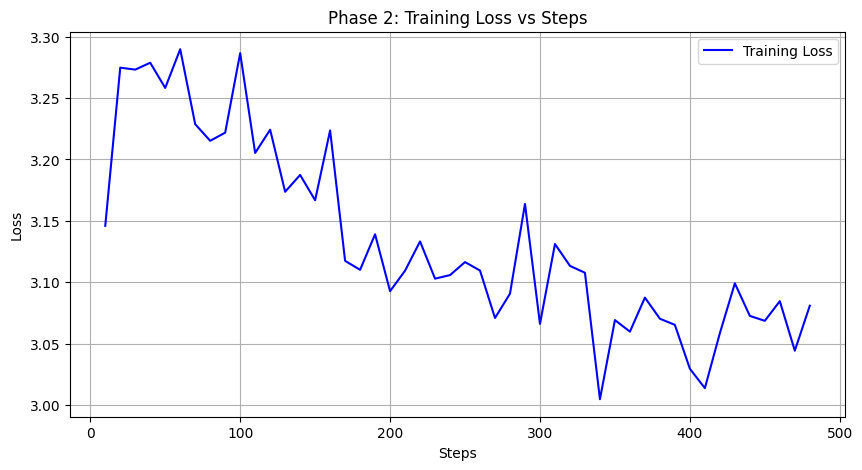

--- Phase 2: Domain Specific Generation Check (Specialist Model) ---
Input Prompt: 'The idiosyncratic reaction to the drug'

Specialist Model Output:
The idiosyncratic reaction to the drug is still unclear though, and one can rule out the possibility that the drugs might increase the risk of relapse.
During the last few years, the development of synthetic opiates has been a significant challenge. The drug
--------------------------------------------------

--- TEST 3: Specialist Model Perplexity Value ---
Loading the new specialist model...
Processing 1328263 tokens... (This may take a minute)
Processed 320000 tokens...
Processed 640000 tokens...
Processed 960000 tokens...
Processed 1280000 tokens...

Specialist Perplexity Score: 17.22
Improvement: 4.68 points lower.
-> SUCCESS: The model is less surprised by medical text!
--------------------------------------------------


In [ ]:
import matplotlib.pyplot as plt

#=== 1. VISUALIZE TRAINING LOSS ===#
# We extract the loss history from the trainer's logs
history = trainer.state.log_history
losses = [x['loss'] for x in history if 'loss' in x]
steps = [x['step'] for x in history if 'loss' in x]

# Plotting logic
plt.figure(figsize=(10, 5))
plt.plot(steps, losses, label='Training Loss', color='blue')
plt.title('Phase 2: Training Loss vs Steps')
plt.xlabel('Steps')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


#=== 2. OBSERVING THE SPECIALIST TEXT GENERATION ===#
model.eval() # evaluation mode (stop dropout)

# 1. Use the EXACT same prompt as Phase 1
input_text = "The idiosyncratic reaction to the drug"
input_ids = tokenizer.encode(input_text, return_tensors="pt").to(device)

print(f"--- Phase 2: Domain Specific Generation Check (Specialist Model) ---")

# 2. Use the EXACT same arguments from Phase 1
output = model.generate(
    input_ids,
    max_length=50,                      # Same as Phase 1
    num_return_sequences=1,    # Same as Phase 1
    do_sample=True,                   # Same as Phase 1
    temperature=0.6,                  # Same as Phase 1
    pad_token_id=tokenizer.eos_token_id
)

generated_text = tokenizer.decode(output[0], skip_special_tokens=True)

print(f"Input Prompt: '{input_text}'")
print(f"\nSpecialist Model Output:\n{generated_text}")
print("-" * 50)


#=== 3. CHECK THE NEW SPECIALIST PERPLEXITY ===#
print(f"\n--- TEST 3: Specialist Model Perplexity Value ---")

# Load the NEW domain-adapted model
print("Loading the new specialist model...")
model_path = "./gpt2-domain-adapted"
# We load it freshly to be 100% sure we are using the trained weights
specialist_model = AutoModelForCausalLM.from_pretrained(model_path).to(device)

# Run the exact same calculator function from Phase 1
new_ppl = calculate_perplexity("pretrain.txt", specialist_model, tokenizer)

print(f"\nSpecialist Perplexity Score: {new_ppl:.2f}")
print(f"Improvement: {baseline_ppl - new_ppl:.2f} points lower.")

if new_ppl < baseline_ppl:
    print("-> SUCCESS: The model is less surprised by medical text!")
else:
    print("-> WARNING: The model did not improve. Check training parameters.")

print("-" * 50)

---

## Phase 3: Changing the Model Behavior (Classification)
Instead of text generation, we now have to replace the LM head with a classification head.
* **Data:** Using `classification.csv` with a 50/50 label distribution.
* **Logic:** I load the weights from `./gpt2-domain-adapted` to ensure that the medical domain knowledge is preserved.
* **Accuracy Calculation:** The accuracy is calculated as (Correct Predictions / Total Samples) across the test set.

In [ ]:
import pandas as pd
from transformers import AutoModelForSequenceClassification
from datasets import Dataset

In [ ]:
#=== 1. PREPARE THE DATA ===#
print("Phase 3: Preparing Classification Data...")

# Load the CSV file into pandas dataframe
df = pd.read_csv("/content/classification.csv")

# Convert the pandas dataframe to a Hugging Face Dataset
dataset = Dataset.from_pandas(df)

# Split into Train (80%) and Test (20%). We need a test set to calculate the Accuracy.
dataset = dataset.train_test_split(test_size=0.2) # returns a dict with keys "train"& "test"


#=== 2. LOAD SPECIALIST MODEL WITH NEW HEAD ===#
model_path = "/content/gpt2-domain-adapted"  # Load the weights I just trained in Phase 2

print(f"Loading weights from {model_path}...")
tokenizer = AutoTokenizer.from_pretrained(model_path)

# GPT-2 needs a pad token for classification
tokenizer.pad_token = tokenizer.eos_token

# Load model with a CLASSIFICATION head (num_labels=2)
# This drops the old "language modeling" head and adds a new one.
model = AutoModelForSequenceClassification.from_pretrained(
    model_path,
    num_labels=2
)
model.config.pad_token_id = model.config.eos_token_id


#=== 3. TOKENIZE ===#
def tokenize_function(examples):
    # Padding="max_length" is important here so all inputs are same size (short sequences will be padded to match the size)
    return tokenizer(
        examples["text"],
        padding="max_length",
        truncation=True,
        max_length=128 # Shorter sequence length for classification is fine
    )

tokenized_datasets = dataset.map(tokenize_function, batched=True)


#=== 4. DEFINE METRICS (ACCURACY) ===#
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    # The model outputs raw numbers (logits). We take the highest one as the prediction.
    predictions = torch.argmax(torch.tensor(logits), dim=-1)

    # Calculate simple accuracy
    acc = accuracy_score(labels, predictions)
    return {"accuracy": acc}


#=== 5. TRAIN THE CLASSIFIER ===#
training_args = TrainingArguments(
    output_dir="./gpt2-classifier",
    num_train_epochs=3,
    per_device_train_batch_size=8,   # Small batch size
    eval_strategy="epoch",     # Check accuracy at end of every epoch
    save_strategy="epoch",
    logging_steps=10,
    learning_rate=2e-5,
    fp16=True,
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["test"],
    compute_metrics=compute_metrics,
)

print("Starting Classification Fine-Tuning...")
trainer.train()


#=== 6. FINAL TEST ===#
print("\nEvaluating on Test Set...")
results = trainer.evaluate()
print(f"Final Accuracy: {results['eval_accuracy']:.2%}")

Phase 3: Preparing Classification Data...
Loading weights from /content/gpt2-domain-adapted...


Some weights of GPT2ForSequenceClassification were not initialized from the model checkpoint at /content/gpt2-domain-adapted and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Map:   0%|          | 0/400 [00:00<?, ? examples/s]

Map:   0%|          | 0/100 [00:00<?, ? examples/s]

Starting Classification Fine-Tuning...


Epoch,Training Loss,Validation Loss,Accuracy
1,0.136500,0.072586,0.990000
2,0.001700,0.035511,0.980000
3,0.019100,0.010838,0.990000



Evaluating on Test Set...


Final Accuracy: 99.00%


---

## Phase 4: Instruction Fine-Tuning
The final phase teaches the model to act as an assistant (chatbot).
* **Formatting:** Data is structured into "instruction" and "response" pairs from `instruct.json`.
* **Observation:** After this tuning, the model should stop generating text after providing the answer rather than rambling.
Fine-tune the model on instruct.json


### 4.1 Fine-tuning

In [ ]:
#=== 1. PREPARE THE DATA (FORMATTING) ===#
print("Phase 4: Formatting Instruction Data...")

# Load your Q&A pairs
with open("/content/instruct.json", "r") as f:
    data = json.load(f)

# We need to format them into a single string like: "Instruction: <question>\nResponse: <answer><EOS>"
formatted_data = []
for item in data:
    # I add the EOS token at the end so the model learns to STOP generating text.
    entry = f"Instruction: {item['instruction']}\nResponse: {item['response']}{tokenizer.eos_token}"
    formatted_data.append(entry)

# Save this temporary file for the trainer to read
with open("instruct_ready.txt", "w", encoding="utf-8") as f:
    f.write("\n".join(formatted_data))


#=== 2. LOAD THE PHASE 2 MODEL (NOT THE CLASSIFIER) ===#
# We go back to the "Generator" we saved in Phase 2
model_path = "/content/gpt2-domain-adapted"
print(f"Loading Specialist Model from {model_path}...")

tokenizer = AutoTokenizer.from_pretrained(model_path)
tokenizer.pad_token = tokenizer.eos_token
model = AutoModelForCausalLM.from_pretrained(model_path).to(device)


#=== 3. TRAIN (INSTRUCTION TUNING) ===#
# Create Dataset
train_dataset = TextDataset(
    tokenizer=tokenizer,
    file_path="instruct_ready.txt",
    block_size=128
)

data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=False
)

training_args = TrainingArguments(
    output_dir="./gpt2-medical-assistant",
    overwrite_output_dir=True,
    num_train_epochs=5,               # Small dataset; multiple epochs allow adaptation at low LR
    per_device_train_batch_size=4,
    gradient_accumulation_steps=4,
    learning_rate=1e-5,
    save_total_limit=1,
    fp16=True,
    logging_steps=2,
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    data_collator=data_collator,
    train_dataset=train_dataset,
)

print("Starting Instruction Tuning...")
trainer.train()

print("-> Training is Completed! Your Medical Assistant is Now Ready.")

Phase 4: Formatting Instruction Data...
Loading Specialist Model from /content/gpt2-domain-adapted...


/usr/local/lib/python3.12/dist-packages/transformers/data/datasets/language_modeling.py:53: FutureWarning: This dataset will be removed from the library soon, preprocessing should be handled with the 🤗 Datasets library. You can have a look at this example script for pointers: https://github.com/huggingface/transformers/blob/main/examples/pytorch/language-modeling/run_mlm.py
  warnings.warn(


Starting Instruction Tuning...


Step,Training Loss
2,3.324100
4,3.153700


-> Training is Completed! Your Medical Assistant is Now Ready.


### 4.2 Interaction

In [ ]:
#=== 4. CHAT WITH YOUR MODEL ===#
print("\n--- MEDICAL ASSISTANT TEST ---")

model.eval() # Set to evaluation mode

def ask_medical_assistant(question):
    # Format the input exactly like we trained it
    prompt = f"Instruction: {question}\nResponse:"

    input_ids = tokenizer.encode(prompt, return_tensors="pt").to(device)

    output = model.generate(
        input_ids,
        max_new_tokens=100,
        eos_token_id=tokenizer.eos_token_id,
        pad_token_id=tokenizer.eos_token_id,
        do_sample=True,
        top_p=0.9,
       temperature=0.7
     )

    # Decode and clean up
    generated_text = tokenizer.decode(output[0], skip_special_tokens=True)

    # We only want the "Response" part, not the instruction repetition
    answer = generated_text.split("Response:")[-1].strip()

    print(f"User: {question}")
    print(f"Bot:  {answer}\n")

def ask_medical_assistant_interactive():
    model.eval()  # make sure model is in eval mode to stop dropout

    while True:
        # Get input from user
        question = input("You: ").strip()
        if question.lower() in ["quit", "exit"]:
            print("Exiting chat...")
            break

        # Format prompt like training
        prompt = f"Instruction: {question}\nResponse:"
        input_ids = tokenizer.encode(prompt, return_tensors="pt").to(model.device)

        with torch.no_grad():
            # Use sampling to avoid repetition loops
            output_ids = model.generate(
                input_ids,
                max_new_tokens=50,
                eos_token_id=tokenizer.eos_token_id,
                pad_token_id=tokenizer.eos_token_id,
                do_sample=True,
                top_p=0.9,
                temperature=0.7
            )

        # Decode output
        decoded = tokenizer.decode(output_ids[0], skip_special_tokens=True)

        # Extract only the response
        answer = decoded.split("Response:")[-1].strip()
        print(f"Bot: {answer}\n")

# Start interactive chat


# Test with a question INSIDE your training set
ask_medical_assistant("What is the primary symptom of hypertension?")

# Test with a question OUTSIDE your training set (Generalization check)
ask_medical_assistant("What is the function of the heart?")

# Test Catastrophic Forgetting (General English)
ask_medical_assistant("How is the weather today?")

# Continue asking interactively
ask_medical_assistant_interactive()



--- MEDICAL ASSISTANT TEST ---
User: What is the primary symptom of hypertension?
Bot:  The most common symptom is a slight headache with fever, headache, dizziness, or nausea. Treatment is based on an understanding of the underlying pathophysiology. The patient is considered to be at risk for a rare or disabling disease, such as diabetes mellitus or hypertension.
This article reviews the literature on the role of hypertension in the development of hypertension in patients with hypertension. Most of the literature is discussed in relation to the clinical and clinical features of hypertension, and the role of the central nervous

User: What is the function of the heart?
Bot:  The heart is a central nervous system organ. Heart rate is regulated by the hypothalamus, the hypothalamus-pituitary gland, and the hypothalamus-pituitary gland. Heart rate and heart rhythm are regulated by the adrenal glands, the pituitary gland, and the hypothalamus. Heart rate and heart rhythm are regulated by 

---